Author(s) : Laura Gómez Navarro, Daniel R. Tarry, ...

Objective: Describe xxx

Created on: May 2023


In [3]:
import time

print('Last update:', time.ctime(time.time()))

Last update: Tue Oct  8 15:31:10 2024


# To improve:
* improve day selection (not with the logical)
* ask why same id num for hereon, but different for carthe
    * carthe 09 dat 24?
    

<a id="0"></a> <br>
# Table of Contents  
1. [Loading the data](#1)     
    1. [Drifters](#1.1.) 
        1. [SVP-B](#1.1.1.) 
        2. [CARTHE](#1.1.2.) 
        3. [HEREON](#1.1.3.) 
    2. [Daily satellite field (SST)](#1.2.) 
    3. [SWOT and transects](#1.3.) 
2. [Plotting all trajectories](#2)
    1. [SVP-B drifters](#2.1.)
        1. [Full trajectories (zoom)](#2.1.1.)
        2. [Full trajectories (full map extent)](#2.1.2.)
        3. [Full trajectories (traj. extent)](#2.1.3.)
    2. [CARTHE](#2.2.)
        1. [Full trajectories (regional zoom)](#2.2.1.)
        2. [Full trajectories (full map extent)](#2.2.2.)
        3. [Full trajectories (traj. extent)](#2.2.3.)
        4. [Only trajectory on day 15/05/23 (+/- 1 day)](#2.2.4.)
        5. [Full trajectories (regional zoom) + Highlight of trajectory on day 15/05/23 (+/- 1 day)](#2.2.5.)
    3. [HEREON](#2.3.)
        1. [Full trajectories (regional zoom)](#2.3.1.)
        2. [Full trajectories (full map extent)](#2.3.2.)
        3. [Full trajectories (traj. extent)](#2.3.3.)
        4. [Only trajectory on day 15/05/23 (+/- 1 day)](#2.3.4.)
        5. [Full trajectories (regional zoom) + Highlight of trajectory on day 15/05/23 (+/- 1 day)](#2.3.5.)
        6. [Extra](#2.3.6.)

In [4]:
#venv py3_parcels_DIAG
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
# LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import xarray as xr
# import cf_xarray
# import folium
# import seawater as sw
# from palettable import cmocean
import cmocean
import datetime
import json
# from erddapy import ERDDAP
import matplotlib.colors as colors
import netCDF4               as netcdf
import matplotlib.gridspec   as gridspec


<a id="1"></a> 
# 1. Loading the data:

### L1 clean data:

In [7]:
!ls ../../../data/drifters/L1_IMEDEA 

dep0001_drifter-svpb039_ime-svpb039_L1_2023-04-26.nc
drifter-svpb035.nc
drifter-svpb038.nc
drifter-svpb039.nc
drifter-svpb040.nc
drifter-svpb041.nc
drifter-svpb042.nc
drifter_carthe006-ime_carthe001.nc
drifter_carthe007-ime_carthe002.nc
drifter_carthe008-ime_carthe003.nc
drifter_carthe009-ime_carthe004.nc
drifter_carthe010-ime_carthe005.nc
drifter_carthe011-ime_carthe006.nc
drifter_carthe012-ime_carthe007.nc
drifter_carthe013-ime_carthe008.nc
drifter_carthe014-ime_carthe009.nc
drifter_carthe015-ime_carthe010.nc
drifter_carthe016-ime_carthe011.nc
drifter_carthe017-ime_carthe012.nc
drifter_carthe018-ime_carthe013.nc
drifter_carthe019-ime_carthe014.nc
drifter_carthe020-ime_carthe015.nc
drifter_carthe021-ime_carthe016.nc
drifter_carthe022-ime_carthe017.nc
drifter_carthe023-ime_carthe018.nc
drifter_carthe024-ime_carthe019.nc
drifter_carthe025-ime_carthe020.nc
drifter_hereon001-ime_hereon001.nc
drifter_hereon002-ime_hereon002.nc
drifter_hereon003-ime_hereon003.nc
drifter_hereon004-ime_hereon

In [8]:
filedir = "../../../data/drifters/L1_IMEDEA/"

<a id="1.1."></a> 
## 1.1. Drifters

<a id="1.1.1."></a> 
### 1.1.1. SVP-B

In [5]:
# url_vars_svp = "trajectory,time[0:1:-1],LAT[0:1:-1],QC_LAT[0:1:-1],LON[0:1:-1],QC_LON[0:1:-1],DEPTH,PSPEED[0:1:-1],QC_PSPEED[0:1:-1],APRE[0:1:-1],QC_APRE[0:1:-1],WTEM[0:1:-1],QC_WTEM[0:1:-1]"

### THE SVP-B drifter of Leg 1 (previous to launch), the cool one in the eddy:
<br>
Surface drifter SCB-SVPB035 (wmo 6102812)
<br>

http://apps.socib.es/dapp/?deployments=2142-30-0

In [6]:
# url_01 = url_root + "drifter_svpb035-scb_svpb035/L1/2023/dep0001_drifter-svpb035_scb-svpb035_L1_2023-02-20.nc?" + url_vars_svp
# ds_svp035 = xr.open_dataset(url_01)

In [7]:
# ds_svp_leg1 = [ds_svp035, ds_svp038, ds_svp039
#                         ,ds_svp040, ds_svp041, ds_svp042]

In [8]:
# svp_leg1_n = ['svp035', 'svp038', 'svp039'
#                         ,'svp040', 'svp041', 'svp042']

<a id="1.1.2."></a> 
### 1.1.2. CARTHE

In [10]:
ds_car010 = xr.open_dataset(filedir + 'drifter_carthe015-ime_carthe010.nc') #*_carthe010.nc --> does not work with *
ds_car010

<xarray.Dataset>
Dimensions:     (time: 266)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-28T01:10:00 ... 2023-04-29T21:2...
Data variables:
    DEPTH       (time) float64 ...
    BAT_STATUS  (time) float64 ...
    LAT         (time) float64 ...
    LON         (time) float64 ...
    U           (time) float64 ...
    V           (time) float64 ...
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE010 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE010 in FaSt-...
    summary:                             Deployment of IME-CARTHE010 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [11]:
mm = '4'.zfill(2)

#8: 27/04
drifter_num = '8'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car008 = xr.open_dataset(url_01)

#07: 27/04
drifter_num = '7'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car007 = xr.open_dataset(url_01)

#06: 27/04
drifter_num = '6'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car006 = xr.open_dataset(url_01)

#05: 27/04
drifter_num = '5'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car005 = xr.open_dataset(url_01)

#04: 27/04
drifter_num = '4'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car004 = xr.open_dataset(url_01)

#03: 26/04
drifter_num = '3'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car003 = xr.open_dataset(url_01)

#02: 26/04
drifter_num = '2'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car002 = xr.open_dataset(url_01)

#01: 26/04
drifter_num = '1'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car001 = xr.open_dataset(url_01)

#09: 24/04
drifter_num = '9'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car009 = xr.open_dataset(url_01)



In [12]:
ds_car_leg1 = [ds_car001, ds_car002, ds_car003
                        , ds_car004, ds_car005, ds_car006, ds_car007, ds_car008 
                       , ds_car009
               , ds_car010]

In [13]:
car_leg1_n = ['car001', 'car002', 'car003'
                ,'car004', 'car005', 'car006', 'car007', 'car008' 
                ,'car009', 'car010']

<a id="1.1.3."></a> 
### 1.1.3. HEREON:

In [14]:
!ls ../../../data/drifters/L1_IMEDEA/

dep0001_drifter-svpb039_ime-svpb039_L1_2023-04-26.nc
drifter-svpb035.nc
drifter-svpb038.nc
drifter-svpb039.nc
drifter-svpb040.nc
drifter-svpb041.nc
drifter-svpb042.nc
drifter_carthe006-ime_carthe001.nc
drifter_carthe007-ime_carthe002.nc
drifter_carthe008-ime_carthe003.nc
drifter_carthe009-ime_carthe004.nc
drifter_carthe010-ime_carthe005.nc
drifter_carthe011-ime_carthe006.nc
drifter_carthe012-ime_carthe007.nc
drifter_carthe013-ime_carthe008.nc
drifter_carthe014-ime_carthe009.nc
drifter_carthe015-ime_carthe010.nc
drifter_carthe016-ime_carthe011.nc
drifter_carthe017-ime_carthe012.nc
drifter_carthe018-ime_carthe013.nc
drifter_carthe019-ime_carthe014.nc
drifter_carthe020-ime_carthe015.nc
drifter_carthe021-ime_carthe016.nc
drifter_carthe022-ime_carthe017.nc
drifter_carthe023-ime_carthe018.nc
drifter_carthe024-ime_carthe019.nc
drifter_carthe025-ime_carthe020.nc
drifter_hereon001-ime_hereon001.nc
drifter_hereon002-ime_hereon002.nc
drifter_hereon003-ime_hereon003.nc
drifter_hereon004-ime_hereon

In [ ]:
url_01 = filedir + "drifter_hereon011-ime_hereon011.nc" 
ds_her011 = xr.open_dataset(url_01)

In [ ]:
mm = '4'.zfill(2)

#10: 28/04
drifter_num = '10'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her010 = xr.open_dataset(url_01)

#09: 27/04
drifter_num = '9'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her009 = xr.open_dataset(url_01)

#08: 27/04
drifter_num = '8'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her008 = xr.open_dataset(url_01)

#07: 27/04
drifter_num = '7'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her007 = xr.open_dataset(url_01)

#06: 27/04
drifter_num = '6'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her006 = xr.open_dataset(url_01)

#04: 27/04
drifter_num = '4'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her004 = xr.open_dataset(url_01)

#03: 26/04
drifter_num = '3'.zfill(3)
dd = '26'.zfill(2)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her003 = xr.open_dataset(url_01)

#02: 26/04
drifter_num = '2'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her002 = xr.open_dataset(url_01)

#01: 26/04
drifter_num = '1'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc" 
ds_her001 = xr.open_dataset(url_01)

In [ ]:
ds_her_leg1 = [ds_her001, ds_her002, ds_her003
                        ,ds_her004, ds_her006, ds_her007, ds_her008
                        ,ds_her009, ds_her010, ds_her011]

In [ ]:
her_leg1_n = ['her001', 'her002', 'her003'
                        ,'her004', 'her006'
              , 'her007', 'her008'
                        ,'her009', 'her010', 'her011']

<a id="1.2."></a> 
## 1.2. Daily satellite field (SST)
(Barbara plot). SST here:

In [ ]:
!ls /Users/Gomez023/Postdoc/develop/FaSt-SWOT/*nc

/Users/Gomez023/Postdoc/develop/FaSt-SWOT/SST_last_6d_sub.nc
/Users/Gomez023/Postdoc/develop/FaSt-SWOT/dSST_last_6d_sub.nc
/Users/Gomez023/Postdoc/develop/FaSt-SWOT/dSST_last_6d_sub_230507_230512.nc
/Users/Gomez023/Postdoc/develop/FaSt-SWOT/ds_CHL_last_6d_sub.nc


In [ ]:
filedir = '/Users/Gomez023/Postdoc/develop/FaSt-SWOT/'

In [ ]:
# ds_sst = xr.open_dataset(filedir + 'dSST_last_6d_sub.nc') # 11 to 16 May
# ds_sst = xr.open_dataset(filedir + 'SST_last_6d_sub.nc') # 04 to 09 Nov 2023
# ds_sst = xr.open_dataset(filedir + 'dSST_last_6d_sub_230507_230512.nc')  # 7 to 12 May 2023
# ds_sst = xr.open_dataset(filedir + 'ds_CHL_last_6d_sub.nc') # 10 to 15 may
ds_sst = xr.open_dataset('../../data/20230426000000-GOS-L3S_GHRSST-SSTsubskin-night_SST_UHR_NRT-MED-v02.0-fv01.0.nc')


In [ ]:
ds_sst.time

<xarray.DataArray 'time' (time: 1)>
array(['2023-04-26T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2023-04-26
Attributes:
    long_name:            reference time of sst field
    standard_name:        time
    axis:                 T
    comment:              Nominal time of Level 4 analysis
    _CoordinateAxisType:  Time

<a id="1.3."></a> 
## 1.3. SWOT and transects

In [ ]:
transect = np.load(filedir + 'FaSt-SWOT2_transect.npz')
#http://localhost:8888/notebooks/FaSt-SWOT/FaST-SWOT2_SST_map_radiator_grid_MVP_CTD_and_gliders_along_swath_edited.ipynb
lon_south=transect['lon_south']
lon_north=transect['lon_north']
lat_south=transect['lat_south']
lat_north=transect['lat_north']

# lon_north=lon_east, lat_south=lat_west, lat_north=lat_east

In [ ]:
dir_swaths = filedir + 'elisabet/'
    
file_swaths1 = 'MED_fastPhase_1km_swotFAST_grid_p009.nc'
file_swaths2 = 'MED_fastPhase_1km_swotFAST_grid_p022.nc'

nc    = netcdf.Dataset(dir_swaths + file_swaths1, 'r')
latsw1  = nc.variables['lat'][:]   
lonsw1  = nc.variables['lon'][:]  
x_ac1   = nc.variables['x_ac'][:]  # "Across track distance from nadir"

lonnd1  = nc.variables['lon_nadir'][:] 
latnd1  = nc.variables['lat_nadir'][:] 
nc.close()     

nc    = netcdf.Dataset(dir_swaths + file_swaths2, 'r')
latsw2  = nc.variables['lat'][:]   
lonsw2  = nc.variables['lon'][:]  
x_ac2   = nc.variables['x_ac'][:]  # "Across track distance from nadir"

lonnd2  = nc.variables['lon_nadir'][:] 
latnd2  = nc.variables['lat_nadir'][:]     

nc.close()  

In [ ]:
ds_sst.time[-1].data

array('2023-04-26T00:00:00.000000000', dtype='datetime64[ns]')

<a id="2"></a> <br>
# 2. Plotting all trajectories:

In [ ]:
def FaSt_SWOT_features(axn, aan, dsn, gs_xn, gs_yn, field=True, sub_uneq=0, map_extent=[.7, 3.0, 38.9, 40.5]):
    """
    axn = axis handle
    dsn = xarray drifter dataset
    field = True or false, if you want to show the SST or Chl. field in the background
    """
    
    axn.set_extent(map_extent, crs=ccrs.PlateCarree())

    # Font and markersizes:
    msize=1
    fsize=14
    
    
    # SWOT swaths
    axn.scatter(lonsw1.flatten(), latsw1.flatten(), c='lavender', s=msize/25, zorder=2, alpha=.5,
                    transform=ccrs.PlateCarree())
    axn.scatter(lonsw2.flatten(), latsw2.flatten(), c='lavender', s=msize/25, zorder=2, alpha=.5,
                    transform=ccrs.PlateCarree())
    axn.scatter(lonnd1.flatten(), latnd1.flatten(), c='lavender', s=msize/25, zorder=2, alpha=.5,
                    transform=ccrs.PlateCarree())
    axn.scatter(lonnd2.flatten(), latnd2.flatten(), c='lavender', s=msize/25, zorder=2, alpha=.5, label='SWOT',
                    transform=ccrs.PlateCarree())

    #Land
    feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                                  scale='10m', zorder=10,
                                                  edgecolor='black', facecolor='#AAAAAA')
    axn.add_feature(feature)

    # Grid and ticks
    gl = axn.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

    gl.top_labels = False
    gl.left_labels = False
    gl.right_labels = False
    if aan < ((gs_y * (gs_x-2)) - sub_uneq): # for horizontal cbar at bottom * (gs_x-1)):
        gl.bottom_labels = False
    if ((aan == 0) | (aan % gs_y == 0)) & (aan < gs_y * (gs_x-1)):  # last and is only valid if colorbar in bottom row
        gl.left_labels = True
    
    gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
    gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}
  
    # Title
    if ds.attrs['instrument_model'] == 'CARTHE':
        axn.set_title(ds.attrs['title'].split(' ')[3].split('-')[-1], size=14) 
    elif ds.attrs['instrument_model'] == 'SVP-B':
        axn.set_title(ds.attrs['title'][-7::], size=14) 
    elif ds.attrs['instrument_model'] == 'Hereon Drifter V2':
        axn.set_title(ds.attrs['title'][-9::], size=14)    
    else:
        print('Error')
        sdgfdsfg
    #20230515 SST field + last day of all drifters', size=16)
    #     'No drifter data: ' + her_leg1_n[ii] + ' ' + str(ds_d07.attrs['instrument_serial']))
    
    # Adding a SST or Chl field:
    if field:
        # fix, see chl notebook 13
        field = (ds_sst.adjusted_sea_surface_temperature[0,:,:] - 273) # Ploting 15/05/23
        # field = np.log10(ds_chl_230506.CHL.squeeze())
        cmap = 'inferno' #cmocean.cm.thermal
        #cbar_label = r'SST ($degrees$)'
        vmin = 16.5  #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
        vmax = 19.2 ##np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
        cs = axn.pcolormesh(
            ds_sst.lon , ds_sst.lat, field,
            cmap = cmap,
            vmin = vmin,
            vmax = vmax,
            transform=ccrs.PlateCarree(),
            shading='auto',
            )
        return cs

In [ ]:
ds_sst

<xarray.Dataset>
Dimensions:                           (time: 1, lat: 601, lon: 481)
Coordinates:
  * time                              (time) datetime64[ns] 2023-04-26
  * lat                               (lat) float32 37.0 37.0 ... 41.99 42.0
  * lon                               (lon) float32 0.9958 1.004 ... 4.988 4.996
Data variables:
    adjusted_sea_surface_temperature  (time, lat, lon) float32 292.5 ... 288.5
    quality_level                     (time, lat, lon) float32 ...
    sea_surface_temperature           (time, lat, lon) float32 ...
    source_of_sst                     (time, lat, lon) float32 ...
Attributes: (12/58)
    Conventions:                CF-1.4
    title:                      Mediterranean SST, L3S, 1km daily (SST_MED_SS...
    summary:                    The MED CNR Sea Surface Temperature L3S produ...
    references:                 Buongiorno Nardelli, B., C. Tronconi, a. Pisa...
    institution:                GOS
    history:                    GOS-MYO processor V3 at UHR res: new version
    ...                         ...
    distribution_statement:     See Copernicus  Marine ServiceData License
    History:                    Translated to CF-1.0 Conventions by Netcdf-Ja...
    geospatial_lat_min:         36.99583435058594
    geospatial_lat_max:         41.99583435058594
    geospatial_lon_min:         0.9958343505859375
    geospatial_lon_max:         4.99583625793457

<a id="2.1"></a> <br>
## 2.1. SVP-B drifters:

<a id="2.1.1."></a> <br>
### 2.1.1. Full trajectories (zoom):

In [ ]:
# aa = 0 # axes index

# plt.close()
# plt.cla
# plt.clf

# gs_x = 3
# gs_y = 3

# ############
# fig = plt.figure(figsize=(14,8))

# gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.49, .49, .02])
# axC = plt.subplot(gs[-1,:])


# ######
# # Leg1 

# # fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# # fig.tight_layout(pad =3.0)

# ## SVP-B:
# for ii, ds in enumerate(ds_svp_leg1):

#     ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
#     cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True) # Plotting SST

#     #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
#     #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

#     #     if ds_m05d07.time.shape[0] == 0 :
#     #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
#     #         continue
#     #     else:
#     ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
#     ax1.scatter(ds.LON[-1], ds.LAT[-1], c='C0', edgecolor='w', linewidths=0.8, transform=ccrs.PlateCarree())
        
#     aa+=1
# ######

# cbar = plt.colorbar(cs,
#             cax=axC,
#             orientation='horizontal',
#             extend='both',
#             #shrink=0.6,
#             #     ticks=np.linspace(vmin,vmax,6),
#             format='%3.2f'
#             )

# cbar_label = r'SST ($^{\circ}$C)'
# cbar.ax.tick_params(labelsize=12)
# cbar.ax.set_xlabel(cbar_label, fontsize=12)

# # plt.tight_layout()
# plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# plt.savefig('SVP-B_drifters_FullTraj_SST_150523_upd01.png', dpi=300)
# # plt.savefig('SVP-B_drifters_FullTraj_SST_150523.png', dpi=300)
# # plt.savefig('SVP-B_drifters_160523_17h45_SST_150523.png', dpi=300) --> overwrote so delted

<a id="2.1.2."></a> <br>
### 2.1.2. Full trajectories (full map extent):

In [ ]:
# aa = 0 # axes index

# plt.close()
# plt.cla
# plt.clf

# gs_x = 3
# gs_y = 3

# ############
# fig = plt.figure(figsize=(14,8))

# gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.49, .49, .02])
# axC = plt.subplot(gs[-1,:])


# ######
# # Leg1 

# # fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# # fig.tight_layout(pad =3.0)

# ## SVP-B:
# for ii, ds in enumerate(ds_svp_leg1):

#     ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
#     cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=0, map_extent=[-0.3, 7.9, 37.9, 41.5]) # Plotting SST

#     #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
#     #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

#     #     if ds_m05d07.time.shape[0] == 0 :
#     #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
#     #         continue
#     #     else:
#     ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
#     ax1.scatter(ds.LON[-1], ds.LAT[-1], c='C0', edgecolor='w', linewidths=0.8, transform=ccrs.PlateCarree())
        
#     aa+=1
# ######

# cbar = plt.colorbar(cs,
#             cax=axC,
#             orientation='horizontal',
#             extend='both',
#             #shrink=0.6,
#             #     ticks=np.linspace(vmin,vmax,6),
#             format='%3.2f'
#             )

# cbar_label = r'SST ($^{\circ}$C)'
# cbar.ax.tick_params(labelsize=12)
# cbar.ax.set_xlabel(cbar_label, fontsize=12)

# # plt.tight_layout()
# plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# # plt.savefig('SVP-B_drifters_150523_15h_SST_150523.png', dpi=300)
# # plt.savefig('SVP-B_drifters_160523_17h45_SST_150523.png', dpi=300) --> overwrote so delted

<a id="2.1.3."></a> <br>
### 2.1.3. Full trajectories (traj. extent):


In [ ]:
# aa = 0 # axes index

# plt.close()
# plt.cla
# plt.clf

# gs_x = 3
# gs_y = 3

# ############
# fig = plt.figure(figsize=(14,8))

# gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.49, .49, .02])
# axC = plt.subplot(gs[-1,:])


# ######
# # Leg1 

# # fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# # fig.tight_layout(pad =3.0)

# ## SVP-B:
# for ii, ds in enumerate(ds_svp_leg1):

#     ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
#     map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
#               ds.LAT.min().values -.1, ds.LAT.max().values +.1]
#     cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=0, map_extent=map_es) # Plotting SST

#     #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
#     #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

#     #     if ds_m05d07.time.shape[0] == 0 :
#     #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
#     #         continue
#     #     else:
#     ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
#     ax1.scatter(ds.LON[-1], ds.LAT[-1], s=80, c='C0', edgecolor='w', linewidths=1.8,
#                 zorder=500, transform=ccrs.PlateCarree())
        
#     aa+=1
# ######

# cbar = plt.colorbar(cs,
#             cax=axC,
#             orientation='horizontal',
#             extend='both',
#             #shrink=0.6,
#             #     ticks=np.linspace(vmin,vmax,6),
#             format='%3.2f'
#             )

# cbar_label = r'SST ($^{\circ}$C)'
# cbar.ax.tick_params(labelsize=12)
# cbar.ax.set_xlabel(cbar_label, fontsize=12)

# # plt.tight_layout()
# plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# # (till june 6th 2023 last plot)
# # plt.savefig('SVP-B_drifters_150523_15h_SST_150523.png', dpi=300)
# # plt.savefig('SVP-B_drifters_160523_17h45_SST_150523.png', dpi=300) --> overwrote so delted

<a id="2.1.4."></a> <br>
### 2.1.4. Only trajectory on day 15/05/23 (+/- 1 day):

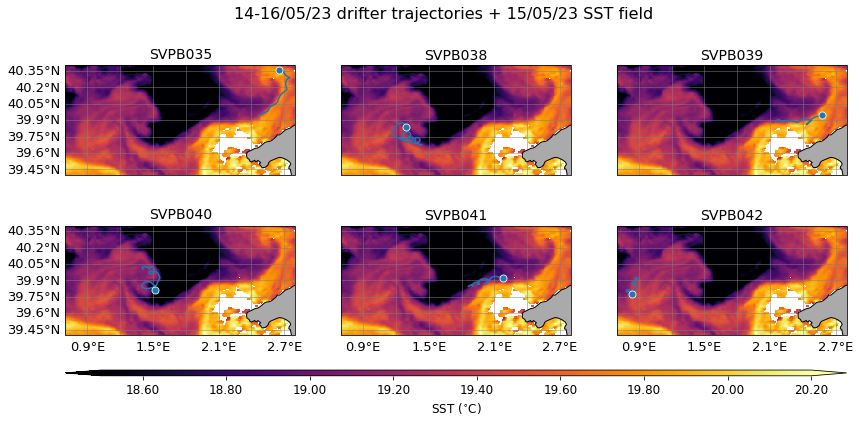

In [ ]:
dd1 = '14'
dd2 = '16'

aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 3
gs_y = 3

############
fig = plt.figure(figsize=(14, 6))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.49, .49, .02])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_svp_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, ds_s, gs_x, gs_y, field=True, map_extent=[0.7, 2.8, 39.4, 40.4], sub_uneq=0, SWOT_swath=False)
    
    ds_s = ds.sel(time=slice("2023-05-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='C0') 
        ax1.scatter(ds_s.LON[-1], ds_s.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())

    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle(dd1 + '-' + dd2 + '/05/23 drifter trajectories + 15/05/23 SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.1.5."></a> <br>
### 2.1.5. Full trajectories (regional zoom) + Highlight of trajectory on day 15/05/23 (+/- 1 day):

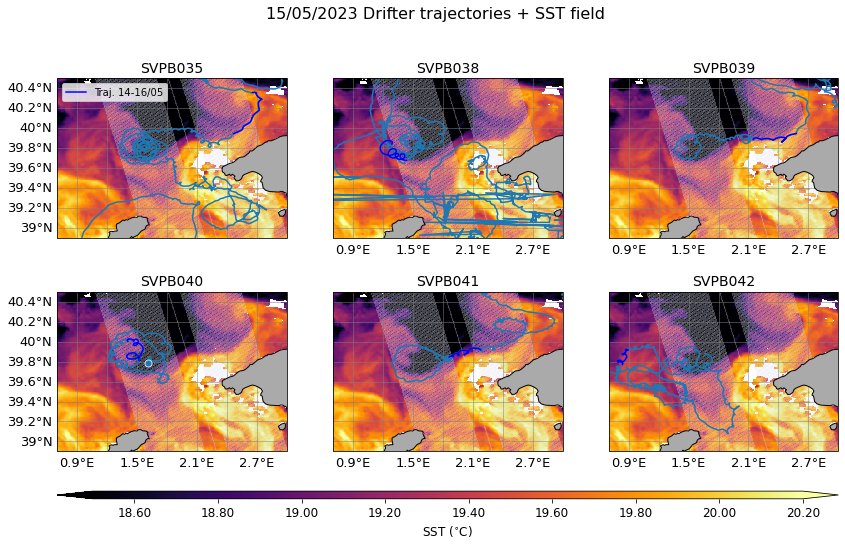

In [137]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 3
gs_y = 3

############
fig = plt.figure(figsize=(14, 8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.49, .49, .02])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_svp_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, ds_s, gs_x, gs_y, field=True, sub_uneq=2)

    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())
    
    ds_s = ds.sel(time=slice("2023-05-14", "2023-05-16"))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='b', label='Traj. 14-16/05') 
        if aa==0:
            ax1.legend(loc=2)
    
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('15/05/2023 Drifter trajectories + SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.2."></a> <br>
## 2.2. CARTHE:

<a id="2.2.1."></a> <br>
### 2.2.1. Full trajectories (regional zoom):

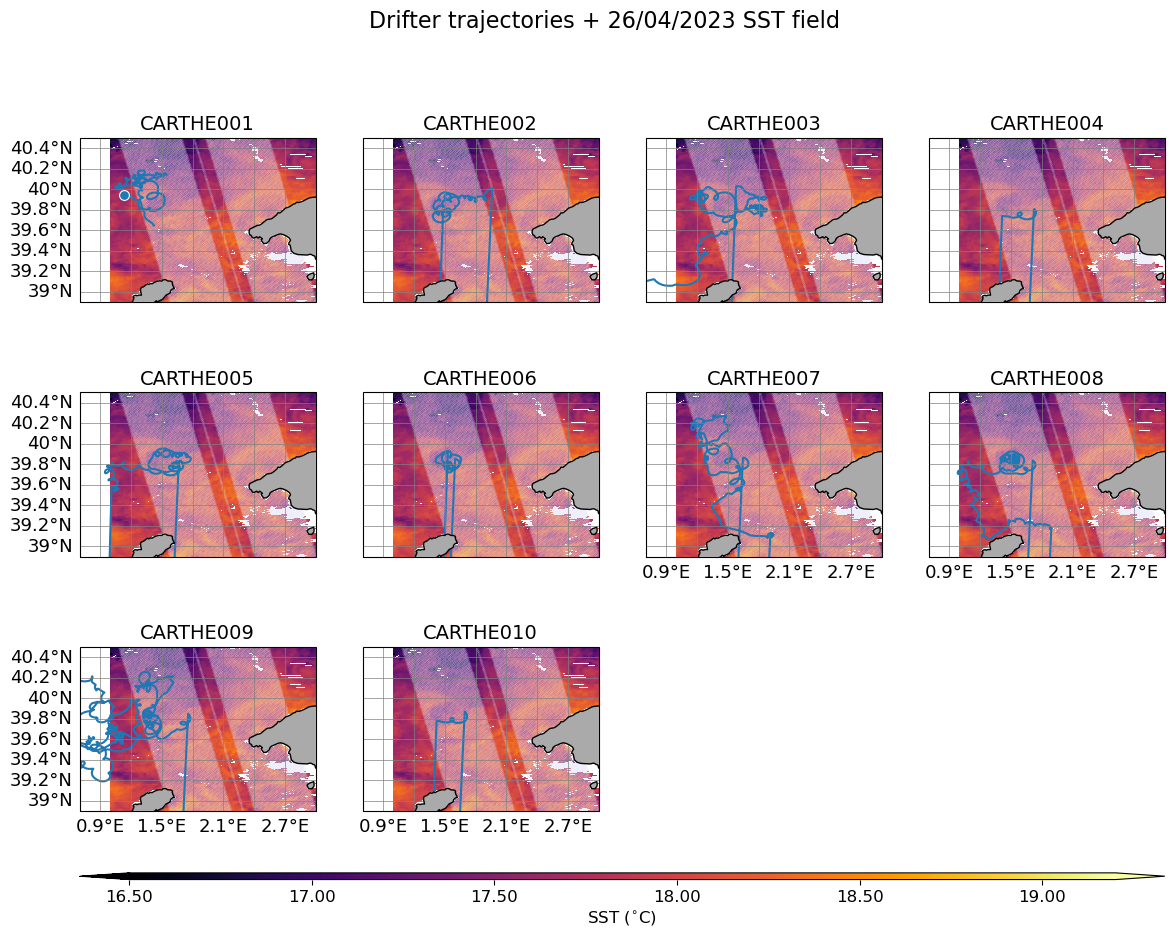

In [68]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14,10))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_car_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=2)

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 26/04/2023 SST field', size=16);

plt.savefig('CARTHE_proc_drifters_FullTraj_SST_260423_upd01.png', dpi=300) 
# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)
# plt.savefig('CARTHE1_drifters_FullTraj_SST_150523.png', dpi=300) #6th June 2023
# plt.savefig('CARTHE1_drifters_160523_17h45_SST_150523.png', dpi=300)
# plt.savefig('CARTHE1_drifters_170523_17h20_SST_150523.png', dpi=300)

(39.5, 40.1)

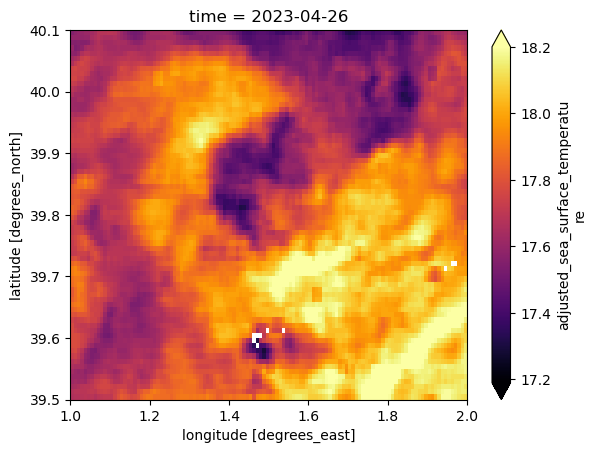

In [63]:
((ds_sst.adjusted_sea_surface_temperature)-273).plot(vmin=17.19, vmax=18.2, cmap='inferno')
plt.xlim([1., 2.])
plt.ylim([39.5, 40.1])

<a id="2.2.2."></a> <br>
### 2.2.2. Full trajectories (full map extent):

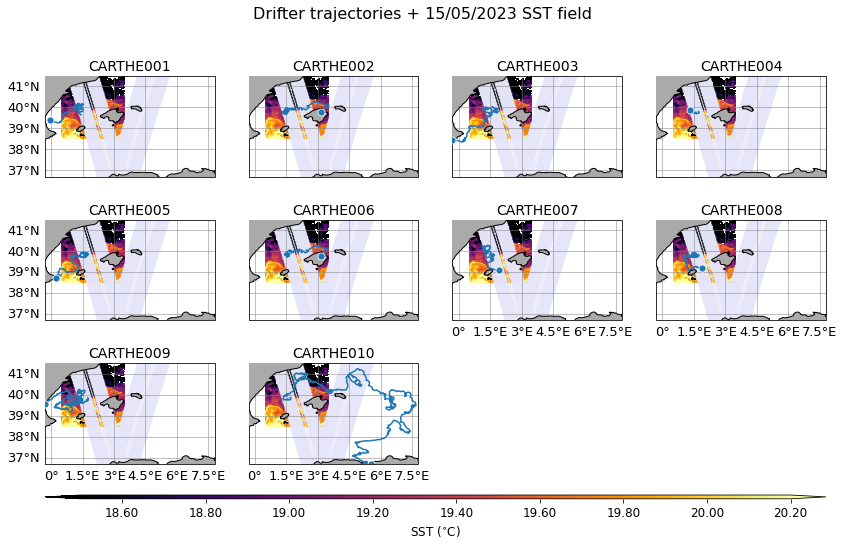

In [40]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_car_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, map_extent=[-0.3, 7.8, 36.7, 41.5], sub_uneq=2)

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.2.3."></a> <br>
### 2.2.3. Full trajectories (traj. extent):


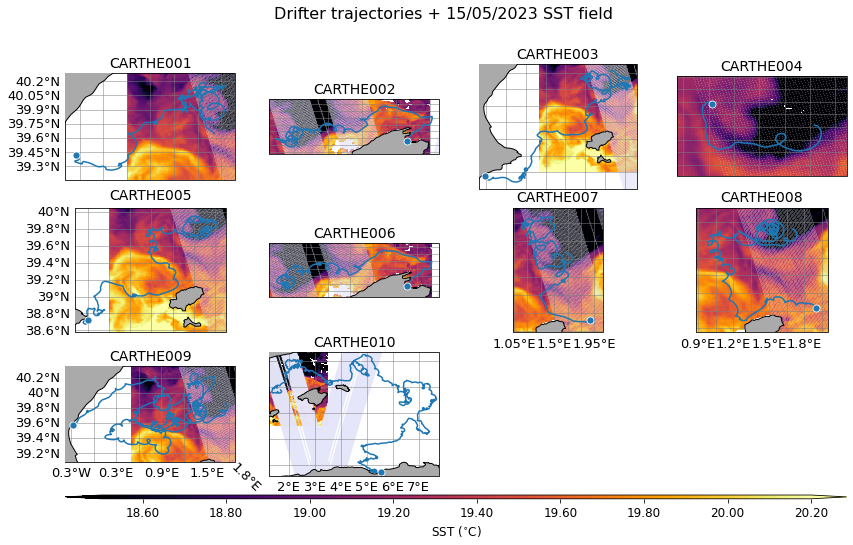

In [41]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_car_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, map_extent=map_es, sub_uneq=2)

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.2.4."></a> <br>
### 2.2.4. Only trajectory on day 15/05/23 (+/- 1 day):

No trajectory segment on these days


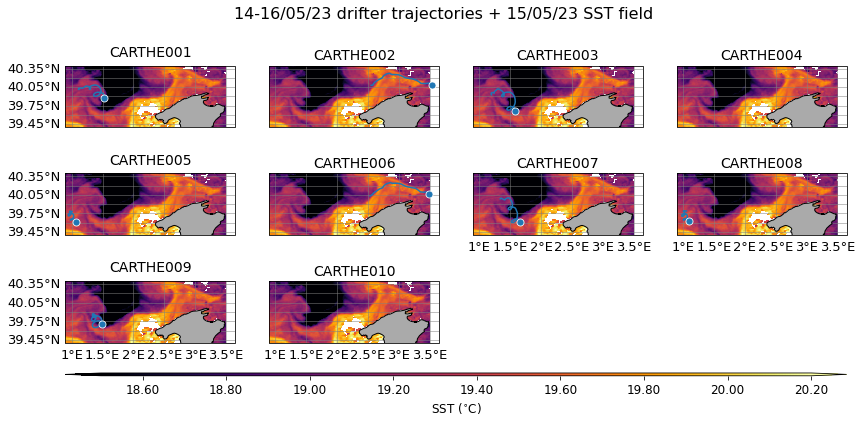

In [121]:
dd1 = '14'
dd2 = '16'

aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 6))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_car_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, ds_s, gs_x, gs_y, field=True, map_extent=[0.9, 3.65, 39.4, 40.4], sub_uneq=2, SWOT_swath=False)
    
    ds_s = ds.sel(time=slice("2023-05-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='C0') 
        ax1.scatter(ds_s.LON[-1], ds_s.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())

    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle(dd1 + '-' + dd2 + '/05/23 drifter trajectories + 15/05/23 SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.2.5."></a> <br>
### 2.2.5. Full trajectories (regional zoom) + Highlight of trajectory on day 15/05/23 (+/- 1 day):

No trajectory segment on these days


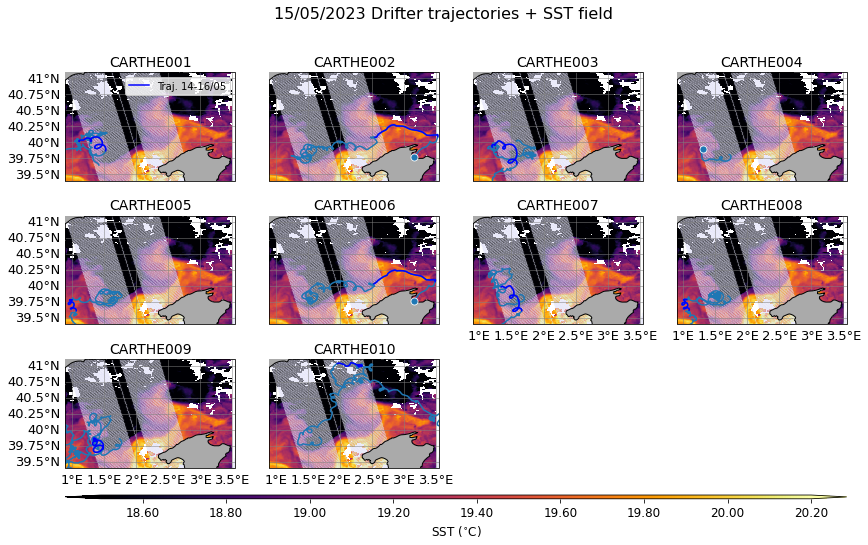

In [116]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_car_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, ds_s, gs_x, gs_y, field=True, map_extent=[0.9, 3.55, 39.4, 41.1], sub_uneq=2)

    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())
    
    ds_s = ds.sel(time=slice("2023-05-14", "2023-05-16"))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='b', label='Traj. 14-16/05') 
        if aa==0:
            ax1.legend(loc=1)
    
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('15/05/2023 Drifter trajectories + SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.3."></a> <br>
## 2.3. HEREON:

<a id="2.3.1."></a> <br>
### 2.3.1. Full trajectories (regional zoom):

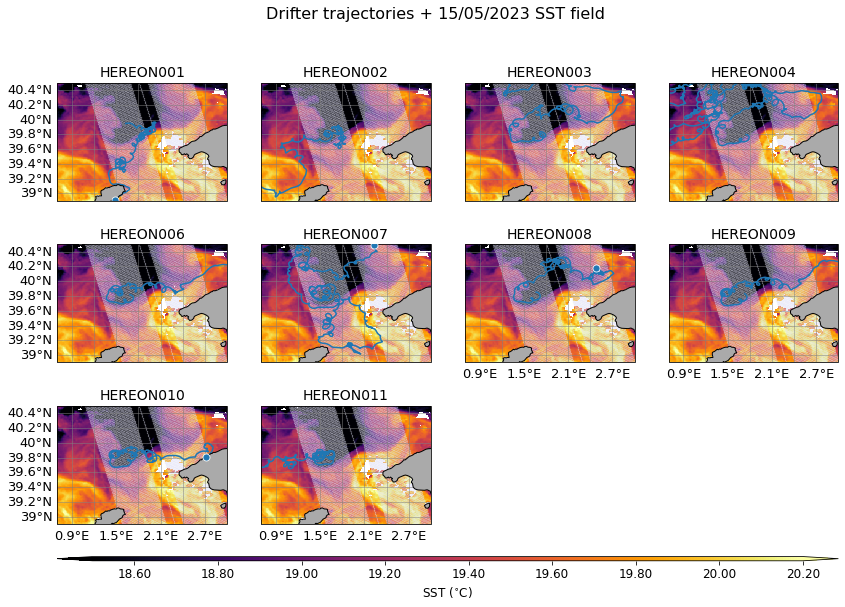

In [72]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 9))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])

######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

for ii, ds in enumerate(ds_her_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=2)#, map_extent=[.7, 3.5, 38.7, 40.7])

    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
    
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# plt.savefig('HEREON_drifters_150523_SST_150523.png', dpi=300)
# plt.savefig('HEREON1_drifters_FullTraj_SST_150523.png', dpi=300) #6th June 23
plt.savefig('HEREON1_drifters_FullTraj_SST_150523_upd01.png', dpi=300)


<a id="2.3.2."></a> <br>
### 2.3.2. Full trajectories (full map extent):

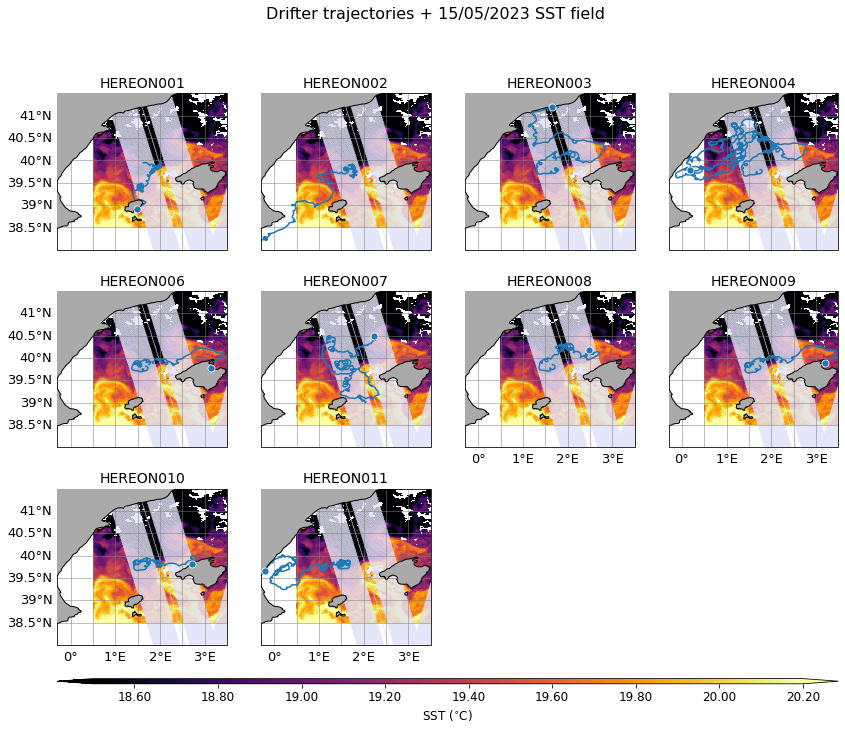

In [73]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14,11))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])

######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

for ii, ds in enumerate(ds_her_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=2, map_extent=[-.3, 3.5, 38., 41.5])

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
    
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# plt.savefig('HEREON_drifters_150523_SST_150523.png', dpi=300)


<a id="2.3.3."></a> <br>
### 2.3.3. Full trajectories (traj. extent):


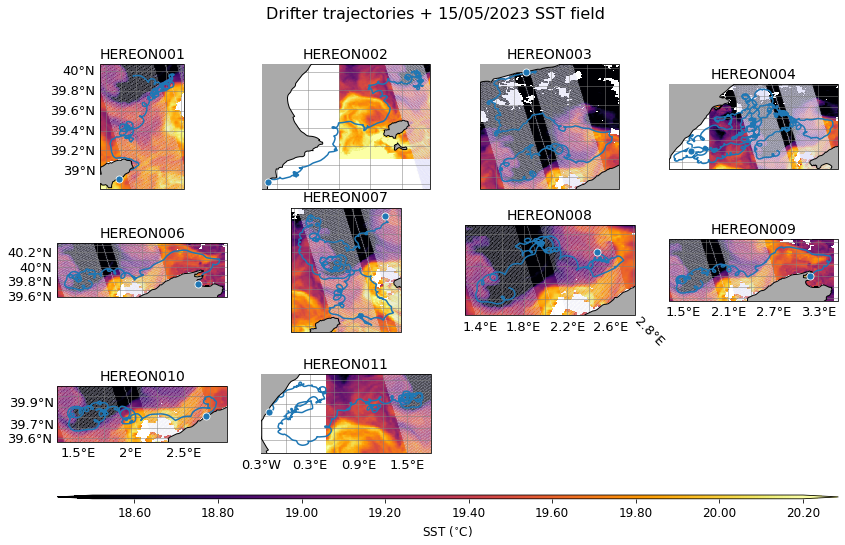

In [74]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_her_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, map_extent=map_es, sub_uneq=2)

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.3.4."></a> <br>
### 2.3.4.  Only trajectory on day 15/05/23 (+/- 1 day):

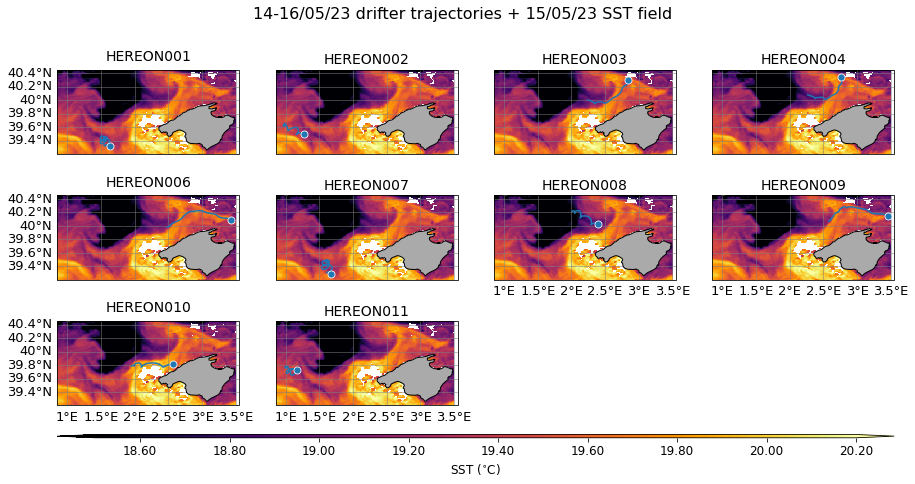

In [111]:
dd1 = '14'
dd2 = '16'

aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(15, 7))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
for ii, ds in enumerate(ds_her_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, ds_s, gs_x, gs_y, field=True, map_extent=[.85, 3.55, 39.2, 40.45], sub_uneq=2, SWOT_swath=False)
    
    ds_s = ds.sel(time=slice("2023-05-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='C0') 
        ax1.scatter(ds_s.LON[-1], ds_s.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())

    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle(dd1 + '-' + dd2 + '/05/23 drifter trajectories + 15/05/23 SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.3.5."></a> <br>
### 2.3.5.  Full trajectories (regional zoom) + Highlight of trajectory on day 15/05/23 (+/- 1 day):

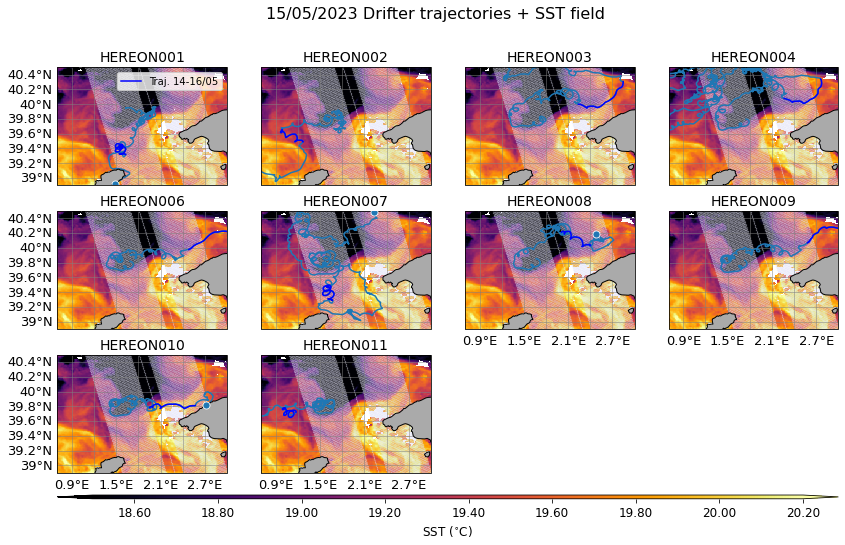

In [119]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_her_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, ds_s, gs_x, gs_y, field=True, sub_uneq=2) #,map_extent=[0.1, 3.5, 38.7, 40.9]

    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())
    
    ds_s = ds.sel(time=slice("2023-05-14", "2023-05-16"))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='b', label='Traj. 14-16/05') 
        if aa==0:
            ax1.legend(loc=1)
    
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('15/05/2023 Drifter trajectories + SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.3.6."></a> <br>
### 2.3.6. Extra
### 15 days from deployment (would need to choose another day for SST image):

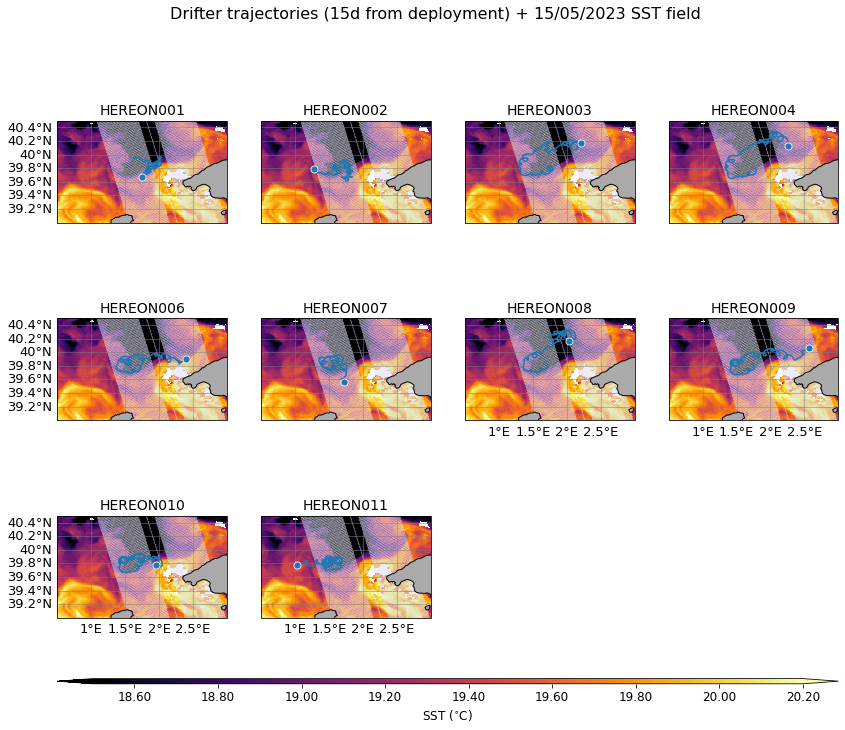

In [121]:
dd2 = '15'

aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14,11))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])

######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

for ii, ds in enumerate(ds_her_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=2, map_extent=[0.5, 3., 39., 40.5])
    
    dd1 = str(ds.time.dt.day.values[0]).zfill(2)
    mm1 = str(ds.time.dt.month.values[0]).zfill(2)    
    dm2 = ds.time.values[0] + np.timedelta64(15, 'D')
    date2 = str(dm2).split('T')[0]
    ds_last = ds.sel(time=slice('2023-' + mm1 + '-' + dd1 + 'T00:00:00', date2 + 'T23:59:59'))
    if ds_last.time.shape[0] == 0 :
        #print('No drifter data')
        continue
    else:
        ax1.plot(ds_last.LON, ds_last.LAT, transform=ccrs.PlateCarree(), c='C0') 
        ax1.scatter(ds_last.LON[-1], ds_last.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
    
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories (15d from deployment) + 15/05/2023 SST field', size=16);

# plt.savefig('HEREON_drifters_150523_SST_150523.png', dpi=300)
